<a href="https://colab.research.google.com/github/FrankChen0930/MarketMamba/blob/main/MarketMamba_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ==========================================
# 🚀 MarketMamba V2: Cell 1 - 資料鍛造廠 (終極防爆版)
# 核心：絕對時間軸對齊 + 儲存輕量化基礎矩陣 (避免 64GB OOM)
# ==========================================
import os
import torch
import numpy as np
import pandas as pd
import yfinance as yf
from tqdm.auto import tqdm
from google.colab import drive

print("🏗️ 啟動 MarketMamba V2 資料鍛造廠 (終極防爆版)...\n")

# ==========================================
# 1. 掛載與路徑設定
# ==========================================
drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/MarketMamba_Database'
RAW_DATA_DIR = os.path.join(BASE_DIR, 'Macro_1D_History')
FEATURE_DIR = os.path.join(BASE_DIR, 'Macro_1D_Features')

os.makedirs(RAW_DATA_DIR, exist_ok=True)
os.makedirs(FEATURE_DIR, exist_ok=True)

# ==========================================
# 2. 獲取宏觀大盤與匯率
# ==========================================
print("🌍 正在連線 Yahoo Finance 獲取總體經濟特徵...")
taiex = yf.download("^TWII", period="max", progress=False)
taiex['Market_Return'] = taiex['Close'].pct_change()

usdtwd = yf.download("USDTWD=X", period="max", progress=False)
usdtwd['USD_TWD'] = usdtwd['Close']

macro_df = pd.DataFrame(index=taiex.index)
macro_df = macro_df.join(taiex['Market_Return']).join(usdtwd['USD_TWD']).ffill().bfill()
macro_df.index = pd.to_datetime(macro_df.index).tz_localize(None)

MACRO_SAVE_PATH = os.path.join(RAW_DATA_DIR, 'TAIEX_Macro.parquet')
macro_df.to_parquet(MACRO_SAVE_PATH)

# ==========================================
# 3. 特徵提煉與絕對時間軸對齊
# ==========================================
files = [f for f in os.listdir(RAW_DATA_DIR) if f.endswith('.parquet') and f != 'TAIEX_Macro.parquet']
all_stocks_data = []
valid_tickers = []

# 🌟 提取大盤的時間軸，作為全市場的「絕對標準」
master_dates = macro_df.index
print(f"\n📏 確立全市場絕對時間軸：共 {len(master_dates)} 個交易日")
print(f"🧪 開始為 {len(files)} 檔股票注入技術指標並強制對齊時間軸...")

for f in tqdm(files, desc="特徵提煉中"):
    ticker = f.split('_')[0]
    df = pd.read_parquet(os.path.join(RAW_DATA_DIR, f))
    df.index = pd.to_datetime(df.index).tz_localize(None)

    # 融合宏觀特徵
    df = df.join(macro_df, how='inner')

    # 計算進階特徵
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA20_Bias'] = (df['Close'] - df['MA20']) / (df['MA20'] + 1e-8)

    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-8)
    df['RSI_14'] = 100 - (100 / (1 + rs))

    df['Daily_Return'] = df['Close'].pct_change()
    df['Vol_10D'] = df['Daily_Return'].rolling(window=10).std()

    df = df.bfill().ffill()

    feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                    'Market_Return', 'USD_TWD', 'MA20_Bias', 'RSI_14', 'Vol_10D']

    # 標準化 (Z-score)
    for col in feature_cols:
        df[col] = (df[col] - df[col].mean()) / (df[col].std() + 1e-8)

    # 🌟 強制對齊並填補空洞
    df_aligned = df[feature_cols].reindex(master_dates)
    df_aligned = df_aligned.ffill().bfill().fillna(0)

    all_stocks_data.append(df_aligned.values)
    valid_tickers.append(ticker)

# ==========================================
# 4. 終極防爆存檔 (只存基礎矩陣，不切片！)
# ==========================================
market_array = np.stack(all_stocks_data, axis=1)
print(f"\n✅ 全市場特徵矩陣構建完成！形狀: {market_array.shape}")

# 轉成 Float32 節省記憶體
market_tensor = torch.tensor(market_array, dtype=torch.float32)
tensor_size_mb = market_tensor.element_size() * market_tensor.nelement() / (1024 * 1024)
print(f"📦 基礎時空矩陣大小: 僅 {tensor_size_mb:.2f} MB (完美避開 OOM 記憶體炸彈！)")

# 安全歸檔至 Macro_1D_Features
TENSOR_SAVE_PATH = os.path.join(FEATURE_DIR, 'market_tensors_v2_base.pt')
torch.save({
    'market_matrix': market_tensor,
    'tickers': valid_tickers,
    'features': feature_cols
}, TENSOR_SAVE_PATH)

print(f"🎉 偉大的 V2 基礎時空矩陣已完美歸檔至: \n 📂 {TENSOR_SAVE_PATH}")

🏗️ 啟動 MarketMamba V2 資料鍛造廠 (終極防爆版)...

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🌍 正在連線 Yahoo Finance 獲取總體經濟特徵...


/tmp/ipykernel_7732/3167083586.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  taiex = yf.download("^TWII", period="max", progress=False)
/tmp/ipykernel_7732/3167083586.py:33: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usdtwd = yf.download("USDTWD=X", period="max", progress=False)



📏 確立全市場絕對時間軸：共 7026 個交易日
🧪 開始為 1937 檔股票注入技術指標並強制對齊時間軸...


特徵提煉中:   0%|          | 0/1937 [00:00<?, ?it/s]


✅ 全市場特徵矩陣構建完成！形狀: (7026, 1937, 10)
📦 基礎時空矩陣大小: 僅 519.16 MB (完美避開 OOM 記憶體炸彈！)
🎉 偉大的 V2 基礎時空矩陣已完美歸檔至: 
 📂 /content/drive/MyDrive/MarketMamba_Database/Macro_1D_Features/market_tensors_v2_base.pt


In [4]:
# ==========================================
# 🩺 MarketMamba V2: Cell 1.5 - 資料庫 X 光體檢中心
# 功能：驗證 V2 基礎矩陣的形狀、大小、以及是否有致命的 NaN/Inf
# ==========================================
import os
import torch
import numpy as np

print("🕵️‍♂️ 啟動 MarketMamba V2 資料庫 X光體檢中心...\n")

FEATURE_DIR = '/content/drive/MyDrive/MarketMamba_Database/Macro_1D_Features'
TENSOR_SAVE_PATH = os.path.join(FEATURE_DIR, 'market_tensors_v2_base.pt')

# 1. 檢查檔案是否存在
if not os.path.exists(TENSOR_SAVE_PATH):
    print(f"❌ 找不到檔案！請確認路徑: {TENSOR_SAVE_PATH}")
else:
    # 2. 嘗試載入資料
    print(f"📦 正在載入時空矩陣，請稍候...")
    try:
        data = torch.load(TENSOR_SAVE_PATH, weights_only=False)
        matrix = data.get('market_matrix')
        tickers = data.get('tickers')
        features = data.get('features')

        print("\n📊 【基礎資料結構檢查】")
        print(f" ┣ 📏 矩陣形狀: {matrix.shape} (預期: 絕對天數, 股票數, 10特徵)")
        print(f" ┣ 🏢 股票數量: {len(tickers)} 檔")
        print(f" ┣ 🧬 特徵數量: {len(features)} 個")
        print(f" ┣ 📝 特徵清單: {', '.join(features)}")
        print(f" ┗ 💾 資料型態: {matrix.dtype}")

        # 3. 檢查實際佔用的記憶體大小
        tensor_size_mb = matrix.element_size() * matrix.nelement() / (1024 * 1024)
        print(f"\n⚖️ 記憶體負載評估: ~{tensor_size_mb:.2f} MB")
        if tensor_size_mb < 2000:
            print(" ✅ 容量極度健康，完全不會撐爆 RAM！")
        else:
            print(" ⚠️ 容量偏大，請小心記憶體限制。")

        # 4. 致命毒藥檢測 (NaN & Inf)
        # 神經網路只要吃到一個 NaN，Loss 就會直接變成 NaN，整個模型就毀了
        print("\n🧪 【致命毒藥 (NaN/Inf) 深度檢測】")
        has_nan = torch.isnan(matrix).any().item()
        has_inf = torch.isinf(matrix).any().item()

        print(f" ┣ NaN (缺失值) 檢測: {'❌ 發現致命 NaN!' if has_nan else '✅ 完美無瑕，無缺失值'}")
        print(f" ┗ Inf (無限大) 檢測: {'❌ 發現致命 Inf!' if has_inf else '✅ 完美無瑕，無無限大數值'}")

        # 5. 隨機抽查數值分佈 (以第一檔股票的第一個特徵為例)
        print(f"\n🔍 【數值分佈抽查 (以 {tickers[0]} 的 {features[0]} 特徵為例)】")
        test_stock_feature = matrix[:, 0, 0]
        # 排除掉因為還沒上市而填補的 0
        non_zero_elements = test_stock_feature[test_stock_feature != 0]

        if len(non_zero_elements) > 0:
            mean_val = non_zero_elements.mean().item()
            std_val = non_zero_elements.std().item()
            print(f" ┣ 活躍交易天數: {len(non_zero_elements)} 天")
            print(f" ┣ 平均值 (Mean): {mean_val:.4f} (Z-score 標準化後應接近 0)")
            print(f" ┗ 標準差 (Std):  {std_val:.4f} (Z-score 標準化後應接近 1)")

        print("\n==========================================")
        if not has_nan and not has_inf:
            print("🎉 體檢報告：SSS 級完美過關！")
            print("🚀 你的 V2 資料庫已經堅不可摧，隨時可以關閉 CPU 機器，換 A100 準備煉丹！")
        else:
            print("⚠️ 體檢報告：發現異常，請勿直接進入訓練！")
        print("==========================================")

    except Exception as e:
        print(f"❌ 檔案讀取失敗，可能是存檔過程中損壞。錯誤訊息: {e}")

🕵️‍♂️ 啟動 MarketMamba V2 資料庫 X光體檢中心...

📦 正在載入時空矩陣，請稍候...

📊 【基礎資料結構檢查】
 ┣ 📏 矩陣形狀: torch.Size([7026, 1937, 10]) (預期: 絕對天數, 股票數, 10特徵)
 ┣ 🏢 股票數量: 1937 檔
 ┣ 🧬 特徵數量: 10 個
 ┣ 📝 特徵清單: Open, High, Low, Close, Volume, Market_Return, USD_TWD, MA20_Bias, RSI_14, Vol_10D
 ┗ 💾 資料型態: torch.float32

⚖️ 記憶體負載評估: ~519.16 MB
 ✅ 容量極度健康，完全不會撐爆 RAM！

🧪 【致命毒藥 (NaN/Inf) 深度檢測】
 ┣ NaN (缺失值) 檢測: ✅ 完美無瑕，無缺失值
 ┗ Inf (無限大) 檢測: ✅ 完美無瑕，無無限大數值

🔍 【數值分佈抽查 (以 4306 的 Open 特徵為例)】
 ┣ 活躍交易天數: 7026 天
 ┣ 平均值 (Mean): -0.1245 (Z-score 標準化後應接近 0)
 ┗ 標準差 (Std):  1.0247 (Z-score 標準化後應接近 1)

🎉 體檢報告：SSS 級完美過關！
🚀 你的 V2 資料庫已經堅不可摧，隨時可以關閉 CPU 機器，換 A100 準備煉丹！


In [1]:
import os
from google.colab import drive

print("🔌 正在掛載 Google Drive...")
drive.mount('/content/drive')

print("\n🚀 啟動 A100 極速武裝程序...")

# 1. 安裝圖神經網路核心套件 (PyTorch Geometric)
print("🕸️ 安裝 torch-geometric...")
!pip install -q torch-geometric

# 2. 尋找並安裝你編譯好的 Mamba 專武 (.whl)
# 假設你的 wheel 檔存在這個資料夾，如果路徑不同請幫我微調一下
WHEEL_DIR = '/content/drive/MyDrive/Mamba_Wheels_A100'

print(f"📦 從 {WHEEL_DIR} 載入預編譯套件...")
!pip install -q {WHEEL_DIR}/causal_conv1d-*.whl
!pip install -q {WHEEL_DIR}/mamba_ssm-*.whl

print("\n==========================================")
print("✅ Cell 1 執行完畢！")
print("A100 環境已完美配置 Mamba 與 GNN 套件！")
print("==========================================")

🔌 正在掛載 Google Drive...
Mounted at /content/drive

🚀 啟動 A100 極速武裝程序...
🕸️ 安裝 torch-geometric...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.7 MB/s eta 0:00:00
📦 從 /content/drive/MyDrive/Mamba_Wheels_A100 載入預編譯套件...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.9 MB/s eta 0:00:00

✅ Cell 1 執行完畢！
A100 環境已完美配置 Mamba 與 GNN 套件！


In [2]:
# ==========================================
# 🚀 MarketMamba V2: Cell 2 - 神經網路大腦建構
# 核心架構：Mamba (時序捕捉) + GAT (空間關聯) + DDPM (降噪預測)
# ==========================================
import torch
import torch.nn as nn
import math
from mamba_ssm import Mamba
from torch_geometric.nn import GATConv

print("🧠 正在建構 MarketMamba V2 神經網路架構...")

# ==========================================
# ⏳ 擴散模型專用：時間步嵌入層 (Time Embedding)
# 告訴模型現在降噪走到第幾步了 (t=100 -> t=0)
# ==========================================
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# ==========================================
# 🐉 終極巨獸：MarketMamba V2 模型主體
# ==========================================
class MarketMambaV2(nn.Module):
    def __init__(self, input_dim=10, d_model=64, num_heads=4):
        # ⚠️ 注意這裡的 input_dim=10，完美對應我們的 10 大特徵！
        super().__init__()
        self.d_model = d_model

        # 1. 歷史特徵升維器 (10維 -> 64維的高維空間)
        self.feature_proj = nn.Linear(input_dim, d_model)

        # 2. Mamba 引擎：負責看懂 120 天的歷史趨勢
        # d_state=16, d_conv=4 都是 Mamba 論文的黃金預設值
        self.mamba = Mamba(
            d_model=d_model,
            d_state=16,
            d_conv=4,
            expand=2,
        )

        # 3. 擴散模型組件
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

        # 把目前為止的雜訊 (noisy_target) 也投射到 64 維
        self.noise_proj = nn.Linear(1, d_model)

        # 4. 圖神經網路 (GAT)：負責股票之間的「連動性」
        # 把 Mamba 抓到的歷史 + 雜訊現況 + 時間步 全部融合後丟給 GAT
        self.gat = GATConv(d_model, d_model // num_heads, heads=num_heads, concat=True)

        # 5. 輸出層：預測出原始加進去的雜訊
        self.output_proj = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, 1) # 最後吐出 1 個數字：預測的雜訊
        )

    def forward(self, x_history, edge_index, noisy_target, time_step):
        # 輸入維度解構
        # x_history: (Batch, 120天, 1937檔, 10特徵)
        # noisy_target: (Batch, 1937檔)
        batch_size, seq_len, num_stocks, _ = x_history.shape

        # --- 步驟 A: Mamba 讀取 120 天歷史 ---
        # 為了讓 Mamba 順利吃資料，我們要把它轉成 (Batch * 1937, 120, 10)
        x_mamba = x_history.permute(0, 2, 1, 3).reshape(batch_size * num_stocks, seq_len, -1)
        x_mamba = self.feature_proj(x_mamba)

        # Mamba 引擎啟動，抓出 120 天的時間序列特徵
        x_mamba = self.mamba(x_mamba)

        # 我們只取最後一天的狀態 (代表吸收了前 119 天的所有精華)
        x_mamba_out = x_mamba[:, -1, :] # (Batch * 1937, 64)
        x_mamba_out = x_mamba_out.reshape(batch_size, num_stocks, self.d_model) # 變回 (Batch, 1937, 64)

        # --- 步驟 B: 擴散模型時間與雜訊處理 ---
        # 處理時間步
        t_emb = self.time_mlp(time_step) # (Batch, 64)
        t_emb = t_emb.unsqueeze(1).expand(-1, num_stocks, -1) # 廣播給 1937 檔股票

        # 處理目標雜訊
        noisy_target = noisy_target.unsqueeze(-1) # (Batch, 1937, 1)
        noise_emb = self.noise_proj(noisy_target) # (Batch, 1937, 64)

        # --- 步驟 C: GNN 股票關聯網路 ---
        # 融合: 歷史(Mamba) + 現況(Noise) + 降噪進度(Time)
        node_features = x_mamba_out + noise_emb + t_emb

        # 一次處理一個 Batch (實戰中可用 PyG 的 DataLoader 優化，這裡為了直觀用迴圈)
        out_list = []
        for b in range(batch_size):
            # 讓 1937 檔股票互相交流訊息
            graph_out = self.gat(node_features[b], edge_index)
            out_list.append(graph_out)

        final_features = torch.stack(out_list) # (Batch, 1937, 64)

        # --- 步驟 D: 輸出預測雜訊 ---
        predicted_noise = self.output_proj(final_features) # (Batch, 1937, 1)
        return predicted_noise.squeeze(-1) # 變回 (Batch, 1937)

print("✅ MarketMambaV2 大腦藍圖繪製完成！")

🧠 正在建構 MarketMamba V2 神經網路架構...
✅ MarketMambaV2 大腦藍圖繪製完成！


In [3]:
# ==========================================
# 🚀 MarketMamba V2: Cell 3 - 動態數據加載與 GNN 關聯網
# 核心：Lazy Loading (動態切片) 解決 OOM 記憶體爆炸
# ==========================================
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

print("🕸️ 啟動動態 DataLoader 與關聯網建構中心...\n")

FEATURE_DIR = '/content/drive/MyDrive/MarketMamba_Database/Macro_1D_Features'
TENSOR_SAVE_PATH = os.path.join(FEATURE_DIR, 'market_tensors_v2_base.pt')

print(f"📦 正在載入基礎時空矩陣 (不佔據過多 RAM)...")
data = torch.load(TENSOR_SAVE_PATH, weights_only=False)

market_matrix = data['market_matrix'] # 形狀: (7026, 1937, 10)
tickers = data['tickers']
num_stocks = market_matrix.shape[1]
print(f"✅ 成功載入！矩陣形狀: {market_matrix.shape}")

# ==========================================
# 🧠 撰寫聰明的 Lazy Loading Dataset
# ==========================================
class MarketDynamicDataset(Dataset):
    def __init__(self, matrix, seq_len=120, pred_window=5):
        self.matrix = matrix
        self.seq_len = seq_len
        self.pred_window = pred_window

        self.total_days = matrix.shape[0]
        # 計算有哪些天數是可以作為「切片終點」的
        self.valid_indices = list(range(seq_len, self.total_days - pred_window))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        # 找到真實的時間點 i
        i = self.valid_indices[idx]

        # 🔪 動態切下過去 120 天 (120, 1937, 10)
        X = self.matrix[i - self.seq_len : i]

        # 🎯 動態計算未來 5 天的報酬率
        current_close = self.matrix[i, :, 3]
        future_close = self.matrix[i + self.pred_window, :, 3]
        Y = future_close - current_close

        return X, Y

# 實例化 Dataset
SEQ_LEN = 120
dataset = MarketDynamicDataset(market_matrix, seq_len=SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, drop_last=True)

# ==========================================
# 🕸️ 構建 GNN 股票關聯網 (用最後 120 天的走勢來建網)
# ==========================================
print("\n📊 正在計算股票歷史連動性，編織 GNN 關聯網...")

# 抓取最後 120 天的收盤價來算相關性
baseline_closes = market_matrix[-SEQ_LEN:, :, 3].T
corr_matrix = torch.nan_to_num(torch.corrcoef(baseline_closes), 0.0)
corr_matrix.fill_diagonal_(0.0)

TOP_K = 10
edges_source, edges_target = [], []

for i in tqdm(range(num_stocks), desc="編織網路"):
    top_k_indices = torch.topk(corr_matrix[i], TOP_K).indices
    for j in top_k_indices:
        edges_source.append(i)
        edges_target.append(j.item())

edge_index = torch.tensor([edges_source, edges_target], dtype=torch.long)
print(f"🕸️ GNN 關聯網建立完成！總共產生了 {edge_index.shape[1]} 條強力邊界。\n")
print("==========================================")
print("🎯 動態 DataLoader 準備就緒！可以進入 Cell 4 煉丹了！")
print("==========================================")

🕸️ 啟動動態 DataLoader 與關聯網建構中心...

📦 正在載入基礎時空矩陣 (不佔據過多 RAM)...
✅ 成功載入！矩陣形狀: torch.Size([7026, 1937, 10])

📊 正在計算股票歷史連動性，編織 GNN 關聯網...


編織網路:   0%|          | 0/1937 [00:00<?, ?it/s]

🕸️ GNN 關聯網建立完成！總共產生了 19370 條強力邊界。

🎯 動態 DataLoader 準備就緒！可以進入 Cell 4 煉丹了！


In [5]:
# ==========================================
# 🚀 MarketMamba V2: Cell 4 - 終極煉丹爐 (智慧早停版)
# ==========================================
import os
import torch
import torch.nn as nn
from torch.optim import AdamW
from tqdm.auto import tqdm

print("🔥 正在為 A100 煉丹爐預熱 (已掛載 Early Stopping 系統)...")

# ==========================================
# 1. 定義擴散模型排程器 (包含加噪數學公式)
# ==========================================
class DDPMScheduler:
    def __init__(self, num_timesteps=100, beta_start=0.0001, beta_end=0.02, device="cuda"):
        self.num_timesteps = num_timesteps
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.device = device

    def add_noise(self, original_samples, noise, timesteps):
        """將乾淨的解答 (Y) 加上特定時間步 (t) 的雜訊"""
        alphas_cumprod_t = self.alphas_cumprod[timesteps]
        sqrt_alpha_prod = torch.sqrt(alphas_cumprod_t).unsqueeze(1) # (Batch, 1)
        sqrt_one_minus_alpha_prod = torch.sqrt(1 - alphas_cumprod_t).unsqueeze(1)
        return sqrt_alpha_prod * original_samples + sqrt_one_minus_alpha_prod * noise

# ==========================================
# 2. 初始化 V2 大腦與基礎設施
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ 目前使用的運算裝置: {device}")

# 實例化大腦 (注意 input_dim=10)
model = MarketMambaV2(input_dim=10, d_model=64, num_heads=4).to(device)
scheduler = DDPMScheduler(num_timesteps=100, device=device)

# 損失函數與優化器
criterion = nn.MSELoss()
optimizer = AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

EPOCHS = 50
SAVE_DIR = '/content/drive/MyDrive/MarketMamba_Database/V2_120D_10F'
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'MarketMamba_V2_Giant.pth')

# ==========================================
# 🛑 Early Stopping 監控雷達設定
# ==========================================
best_loss = float('inf') # 初始最佳 Loss 設為無限大
patience = 5             # 耐心值：容忍幾圈沒進步
patience_counter = 0     # 目前已經幾圈沒進步了
min_delta = 0.0001       # 最小進步幅度 (避免微小震盪干擾)

print("\n🚀 點火！MarketMamba V2 訓練正式開始...")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch_idx, (X_batch, Y_batch) in enumerate(progress_bar):
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        batch_size = X_batch.shape[0]

        timesteps = torch.randint(0, scheduler.num_timesteps, (batch_size,), device=device).long()
        noise = torch.randn_like(Y_batch)
        y_noisy = scheduler.add_noise(Y_batch, noise, timesteps)

        optimizer.zero_grad()
        predicted_noise = model(X_batch, edge_index.to(device), y_noisy, timesteps)

        loss = criterion(predicted_noise, noise)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()

        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_loss = total_loss / len(dataloader)
    print(f"📈 Epoch {epoch+1} 總結 | 平均 Loss: {avg_loss:.5f}")

    # ==========================================
    # 🛑 Early Stopping 邏輯判定
    # ==========================================
    if avg_loss < best_loss - min_delta:
        print(f"🎉 發現更低 Loss ({best_loss:.5f} -> {avg_loss:.5f})！正在備份最佳大腦...")
        best_loss = avg_loss
        patience_counter = 0
        # ⚠️ 只有打破紀錄的時候才存檔！
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    else:
        patience_counter += 1
        print(f"⚠️ Loss 未顯著下降，耐心值消耗: {patience_counter} / {patience}")

    if patience_counter >= patience:
        print(f"\n🛑 觸發 Early Stopping！Loss 已經連續 {patience} 圈沒有進步。")
        print(f"🛑 為了節省 A100 算力與你的時間，提早結束訓練！")
        break

print("\n🎉 訓練任務圓滿結束！")
print(f"💾 你現在擁有的是 Loss = {best_loss:.5f} 的最精銳 V2 大腦！")

🔥 正在為 A100 煉丹爐預熱 (已掛載 Early Stopping 系統)...
🖥️ 目前使用的運算裝置: cuda

🚀 點火！MarketMamba V2 訓練正式開始...


Epoch 1/50:   0%|          | 0/431 [00:00<?, ?it/s]

📈 Epoch 1 總結 | 平均 Loss: 0.71332
🎉 發現更低 Loss (inf -> 0.71332)！正在備份最佳大腦...


Epoch 2/50:   0%|          | 0/431 [00:00<?, ?it/s]

📈 Epoch 2 總結 | 平均 Loss: 0.23235
🎉 發現更低 Loss (0.71332 -> 0.23235)！正在備份最佳大腦...


...

📈 Epoch 18 總結 | 平均 Loss: 0.15428
⚠️ Loss 未顯著下降，耐心值消耗: 3 / 5


Epoch 19/50:   0%|          | 0/431 [00:00<?, ?it/s]

📈 Epoch 19 總結 | 平均 Loss: 0.13296
⚠️ Loss 未顯著下降，耐心值消耗: 4 / 5


Epoch 20/50:   0%|          | 0/431 [00:00<?, ?it/s]

📈 Epoch 20 總結 | 平均 Loss: 0.11674
⚠️ Loss 未顯著下降，耐心值消耗: 5 / 5

🛑 觸發 Early Stopping！Loss 已經連續 5 圈沒有進步。
🛑 為了節省 A100 算力與你的時間，提早結束訓練！

🎉 訓練任務圓滿結束！
💾 你現在擁有的是 Loss = 0.11491 的最精銳 V2 大腦！


In [7]:
# ==========================================
# 🚀 MarketMamba V2: Cell 5 - 終極回測與風險評估中心 (Lazy Loading 適配版)
# ==========================================
import os
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import mean_absolute_error

print("📊 啟動 MarketMamba V2 回測與評估中心...\n")

# ==========================================
# 1. 基礎設施與大腦載入
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 📁 模型權重路徑 (在 V2 專屬資料夾)
MODEL_PATH = '/content/drive/MyDrive/MarketMamba_Database/V2_120D_10F/MarketMamba_V2_Giant.pth'

# 📁 基礎時空矩陣路徑 (在 Features 資料夾)
FEATURE_DIR = '/content/drive/MyDrive/MarketMamba_Database/Macro_1D_Features'
TENSOR_PATH = os.path.join(FEATURE_DIR, 'market_tensors_v2_base.pt')

# 📦 載入防爆基礎資料庫
print("📦 載入 V2 基礎時空矩陣...")
data = torch.load(TENSOR_PATH, weights_only=False)
market_matrix = data['market_matrix'] # 形狀: (總天數, 1937, 10)
tickers = data['tickers']
total_days = market_matrix.shape[0]

# 🧠 喚醒大腦
print("🧠 喚醒 MarketMamba V2 巨獸大腦...")
model = MarketMambaV2(input_dim=10, d_model=64, num_heads=4)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device)
model.eval()

# 重建降噪排程器 (設定必須與訓練時完全相同)
scheduler = DDPMScheduler(num_timesteps=100, device=device)

# ==========================================
# 2. 動態切出歷史考卷 & 編織當下 GNN
# ==========================================
# 設定回測時間點：我們拿「有完整未來 5 天解答」的最新倒數第 100 天來當考點
SEQ_LEN = 120
PRED_WINDOW = 5
test_i = total_days - PRED_WINDOW - 100

print(f"\n🔪 正在動態切出第 {test_i} 天的 120 天時空磚塊...")
# 切下過去 120 天作為輸入 (1, 120, 1937, 10)
test_x = market_matrix[test_i - SEQ_LEN : test_i].clone().detach().unsqueeze(0).to(device)

# 抓取真實解答 (未來第 5 天收盤 - 當下收盤)
current_close = market_matrix[test_i, :, 3]
future_close = market_matrix[test_i + PRED_WINDOW, :, 3]
true_y = (future_close - current_close).numpy()

print(f"🕸️ 正在根據測試當下的軌跡，動態編織 GNN 關聯網...")
# 提取測試節點當下的 120 天收盤價
test_closes = test_x[0, :, :, 3].cpu().T
corr_matrix = torch.nan_to_num(torch.corrcoef(test_closes), 0.0)
corr_matrix.fill_diagonal_(0.0)

edges_source, edges_target = [], []
TOP_K = 10
for i in range(len(tickers)):
    top_k_indices = torch.topk(corr_matrix[i], TOP_K).indices
    for j in top_k_indices:
        edges_source.append(i)
        edges_target.append(j.item())

test_edge_index = torch.tensor([edges_source, edges_target], dtype=torch.long).to(device)

# ==========================================
# 3. 擴散模型預測 (平行宇宙展開)
# ==========================================
@torch.no_grad()
def generate_future_distributions(model, scheduler, x_latest, edge_idx, num_futures=30):
    num_stocks = x_latest.shape[2]
    x_history_expanded = x_latest.expand(num_futures, -1, -1, -1)
    x_t = torch.randn(num_futures, num_stocks, device=device)

    for i in tqdm(reversed(range(scheduler.num_timesteps)), total=scheduler.num_timesteps, desc="🌌 回測降噪生成中"):
        t = torch.full((num_futures,), i, device=device, dtype=torch.long)
        predicted_noise = model(x_history_expanded, edge_idx, x_t, t)

        alpha_t = scheduler.alphas[i]
        alpha_t_cumprod = scheduler.alphas_cumprod[i]
        beta_t = scheduler.betas[i]

        noise = torch.randn_like(x_t) if i > 0 else torch.zeros_like(x_t)
        x_t = (1 / torch.sqrt(alpha_t)) * (x_t - ((1 - alpha_t) / torch.sqrt(1 - alpha_t_cumprod)) * predicted_noise) + torch.sqrt(beta_t) * noise
    return x_t

print(f"\n⏳ 正在展開 30 個平行宇宙預測...")
future_returns = generate_future_distributions(model, scheduler, test_x, test_edge_index, num_futures=30)

# ==========================================
# 4. 產出 V2 終極成績單 (夏普指標邏輯)
# ==========================================
pred_mean = future_returns.mean(dim=0).cpu().numpy()
pred_std = future_returns.std(dim=0).cpu().numpy()
pred_std = np.clip(pred_std, a_min=1e-6, a_max=None)

# 🏆 風險調整後分數 (Score = 預期報酬 / 波動風險)
risk_adjusted_score = pred_mean / pred_std

df_eval = pd.DataFrame({
    'Ticker': tickers,
    'Predicted_Mean': pred_mean,
    'Predicted_Std': pred_std,
    'Risk_Adjusted_Score': risk_adjusted_score,
    'True_Return': true_y
})

mae = mean_absolute_error(true_y, pred_mean)
ic_value = df_eval['Predicted_Mean'].corr(df_eval['True_Return'], method='spearman')

# V2 夏普選股法：預期報酬為正，且 Score 排名最高的前 10 檔
positive_picks = df_eval[df_eval['Predicted_Mean'] > 0]
top_10_picks = positive_picks.sort_values('Risk_Adjusted_Score', ascending=False).head(10)
actual_profit = top_10_picks['True_Return'].mean()

print("\n==========================================")
print("📝 【MarketMamba V2 終極成績單】 📝")
print("==========================================")
print(f"🥇 資訊係數 (Rank IC): {ic_value:.4f}")
print(f"📏 預測平均絕對誤差 (MAE): {mae:.4f}")
print("------------------------------------------")
print("🏆 【V2 夏普選股法：兼顧獲利與防禦的 Top 10】")
print(top_10_picks[['Ticker', 'Predicted_Mean', 'Predicted_Std', 'Risk_Adjusted_Score', 'True_Return']].to_string(index=False))
print("------------------------------------------")
print(f"💰 實戰模擬報酬率: {actual_profit * 100:.2f}% (5天期間)")
print("==========================================")

📊 啟動 MarketMamba V2 回測與評估中心...

📦 載入 V2 基礎時空矩陣...
🧠 喚醒 MarketMamba V2 巨獸大腦...

🔪 正在動態切出第 6921 天的 120 天時空磚塊...
🕸️ 正在根據測試當下的軌跡，動態編織 GNN 關聯網...

⏳ 正在展開 30 個平行宇宙預測...


🌌 回測降噪生成中:   0%|          | 0/100 [00:00<?, ?it/s]


📝 【MarketMamba V2 終極成績單】 📝
🥇 資訊係數 (Rank IC): 0.0928
📏 預測平均絕對誤差 (MAE): 0.1027
------------------------------------------
🏆 【V2 夏普選股法：兼顧獲利與防禦的 Top 10】
Ticker  Predicted_Mean  Predicted_Std  Risk_Adjusted_Score  True_Return
  3067        0.049156       0.042209             1.164596     0.110851
  6641        0.055404       0.049459             1.120207    -0.026653
  5301        0.075224       0.070347             1.069334    -0.001342
  4745        0.032576       0.030508             1.067797     0.015739
  4171        0.065672       0.061548             1.067012    -0.004697
  6856        0.067323       0.065315             1.030732     0.259462
  5907        0.053934       0.053821             1.002091    -0.007024
  5011        0.040450       0.041248             0.980662     0.017355
  4190        0.042102       0.044117             0.954328    -0.010569
  6844        0.042120       0.046695             0.902030    -0.166400
------------------------------------------
💰 實戰模擬報酬率: 1.87

🔭 啟動 MarketMamba V2 平行宇宙觀測儀...



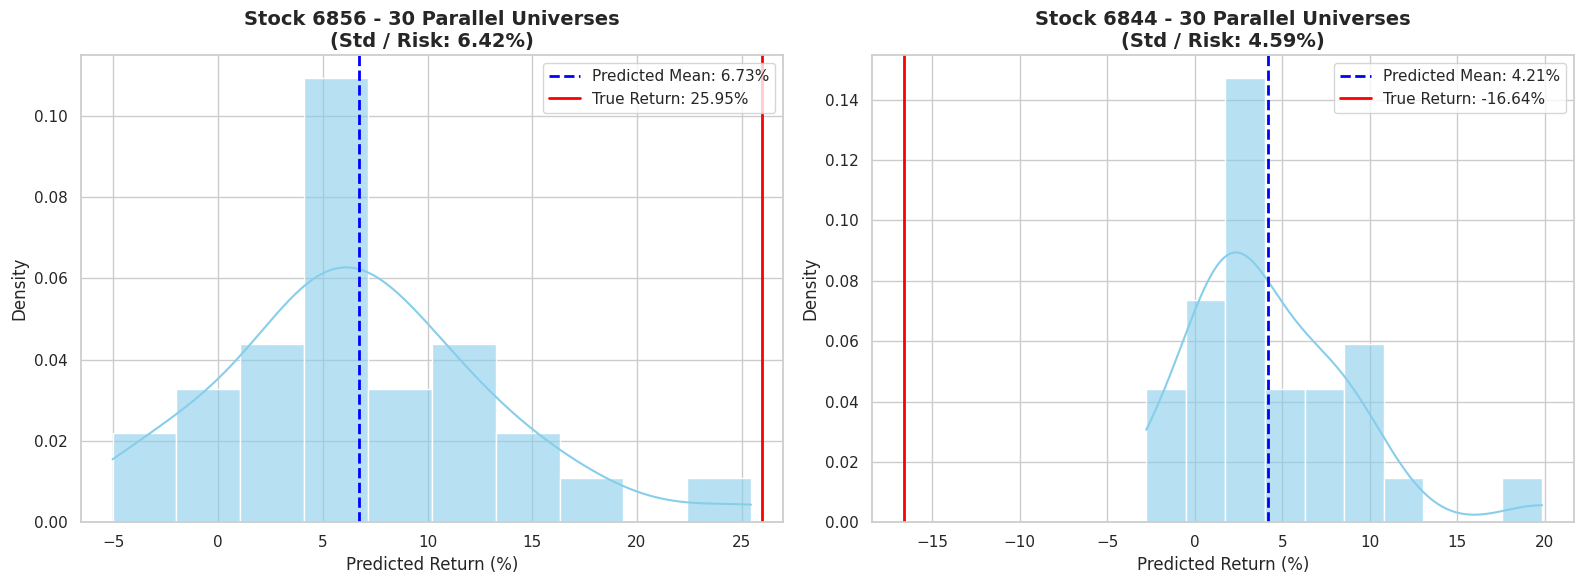

💡 【觀測指南】
1. 鐘形罩的『寬度』代表模型的『不確定性 (風險)』。
2. 藍線是模型看好的方向，紅線是現實世界的殘酷真相。
3. 如果紅線落在鐘形罩的極端邊緣，代表發生了『黑天鵝事件』。


In [8]:
# ==========================================
# 🔭 MarketMamba V2: Cell 6 - 平行宇宙觀測儀 (機率密度分佈)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🔭 啟動 MarketMamba V2 平行宇宙觀測儀...\n")

# 我們要觀察的兩檔極端案例
target_stocks = ['6856', '6844']
# 為了中文字體在 Colab 能正常顯示，通常用英文標籤比較安全
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, target_ticker in enumerate(target_stocks):
    # 找出這檔股票在 tickers 陣列中的索引
    if target_ticker in tickers:
        stock_idx = tickers.index(target_ticker)

        # 抓出這檔股票的 30 個平行宇宙預測結果 (轉成百分比)
        # future_returns shape 是 (30, 1937)
        universe_predictions = future_returns[:, stock_idx].cpu().numpy() * 100

        # 抓出真實的報酬率 (轉成百分比)
        actual_return = true_y[stock_idx] * 100
        mean_pred = universe_predictions.mean()
        std_pred = universe_predictions.std()

        ax = axes[idx]

        # 繪製機率密度雲 (KDE) 與直方圖
        sns.histplot(universe_predictions, kde=True, ax=ax, color="skyblue", bins=10, stat="density", alpha=0.6)

        # 畫上「模型預期平均值」的輔助線 (藍色虛線)
        ax.axvline(mean_pred, color='blue', linestyle='--', linewidth=2, label=f'Predicted Mean: {mean_pred:.2f}%')

        # 畫上「真實發生結果」的輔助線 (紅色實線)
        ax.axvline(actual_return, color='red', linestyle='-', linewidth=2, label=f'True Return: {actual_return:.2f}%')

        # 設定標題與圖例
        ax.set_title(f'Stock {target_ticker} - 30 Parallel Universes\n(Std / Risk: {std_pred:.2f}%)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted Return (%)', fontsize=12)
        ax.set_ylabel('Density', fontsize=12)
        ax.legend()

    else:
        print(f"⚠️ 找不到股票 {target_ticker} 的資料。")

plt.tight_layout()
plt.show()

print("==========================================")
print("💡 【觀測指南】")
print("1. 鐘形罩的『寬度』代表模型的『不確定性 (風險)』。")
print("2. 藍線是模型看好的方向，紅線是現實世界的殘酷真相。")
print("3. 如果紅線落在鐘形罩的極端邊緣，代表發生了『黑天鵝事件』。")
print("==========================================")